# Traveling Salesman Problem - Genetski Algoritam
Problem trgovačkog putnika (TSP) je jedan od najpoznatijih problema u kombinatornoj optimizaciji. Cilj je pronaći najkraću rutu koja prolazi kroz sve gradove točno jednom i vraća se u početni grad.

**Autori**: Matej Muller i Gabriel Beronja

**Fakultet**: Fakultet informatike u Puli

**Kolegij**: Robotika

## Uvoz potrebnih biblioteka

U ovom segmentu uvozimo sve potrebne biblioteke za implementaciju genetskog algoritma. NumPy koristimo za efikasno rukovanje numeričkim operacijama i koordinatama gradova, matplotlib za kreiranje vizualizacija ruta i grafova konvergencije, random za generiranje slučajnih brojeva potrebnih u genetskim operatorima, deepcopy za sigurno kopiranje objekata bez mijenjanja originala, a time modul za mjerenje performansi algoritma.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from copy import deepcopy
from time import time

## Konfiguracija osnovnih parametara problema

Ovdje definiramo sve ključne parametre našeg genetskog algoritma. NUM_CITIES određuje koliko gradova ćemo imati u problemu, COORDINATE_RANGE definira opseg koordinata za generiranje pozicija gradova. POPULATION_SIZE, GENERATIONS, MUTATION_RATE, ELITE_SIZE i TOURNAMENT_SIZE su parametri koji direktno utječu na performanse genetskog algoritma. Također generiramo nasumične koordinate gradova koristeći NumPy, pri čemu postavljamo seed za reproducibilnost rezultata.

In [ ]:
# Parametri problema
NUM_CITIES = 30
COORDINATE_RANGE = 100
POPULATION_SIZE = 100
GENERATIONS = 500
MUTATION_RATE = 0.2
ELITE_SIZE = 1
TOURNAMENT_SIZE = 3

# Generiranje slučajnih koordinata gradova
np.random.seed(42)  # Za reproducibilnost rezultata
cities = np.random.rand(NUM_CITIES, 2) * COORDINATE_RANGE

print(f"Generirano je {NUM_CITIES} gradova u koordinatnom sustavu {COORDINATE_RANGE}x{COORDINATE_RANGE}")

Generirano je 30 gradova u koordinatnom sustavu 100x100


## Implementacija pomoćnih funkcija za računanje udaljenosti
Implementiramo osnovne funkcije potrebne za rad s koordinatama gradova. Funkcija `euclidean_distance` koristi NumPy za efikasno računanje euklidske udaljenosti između dva grada pomoću `np.linalg.norm`. Funkcija `create_distance_matrix` kreira simetričnu matricu koja sadrži udaljenosti između svih parova gradova - ova matrica se koristi tijekom cijelog algoritma za brže računanje fitness vrijednosti.

In [ ]:
def euclidean_distance(city1, city2):
    """
    Izračunava euklidsku udaljenost između dva grada.

    Args:
        city1, city2: numpy array koordinata gradova

    Returns:
        float: udaljenost između gradova
    """
    return np.linalg.norm(city1 - city2)

def create_distance_matrix(cities):
    """
    Kreira matricu udaljenosti između svih parova gradova.

    Args:
        cities: numpy array koordinata svih gradova

    Returns:
        numpy array: matrica udaljenosti
    """
    n = len(cities)
    distance_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            distance_matrix[i][j] = euclidean_distance(cities[i], cities[j])

    return distance_matrix

# Kreiranje matrice udaljenosti
distance_matrix = create_distance_matrix(cities)
print(f"Kreirana matrica udaljenosti dimenzija {distance_matrix.shape}")

Kreirana matrica udaljenosti dimenzija (30, 30)


## Definiranje fitness funkcije
Fitness funkcija je srce našeg genetskog algoritma - ona evaluira kvalitetu svake rute u populaciji. U TSP problemu, cilj je minimizirati ukupnu udaljenost, pa je ova funkcija odgovorna za računanje sume svih udaljenosti između susjednih gradova u ruti. Koristimo modulo operator da se osiguramo da se zadnji grad povezuje s prvim, čime zatvaramo krug i vraćamo putnika na početnu poziciju.

In [ ]:
def calculate_total_distance(path, distance_matrix):
    """
    Izračunava ukupnu udaljenost rute.

    Args:
        path: lista redoslijeda obilaska gradova
        distance_matrix: matrica udaljenosti između gradova

    Returns:
        float: ukupna udaljenost rute
    """
    total_distance = 0
    path_length = len(path)

    for i in range(path_length):
        current_city = path[i]
        next_city = path[(i + 1) % path_length]  # Povratak na početak
        total_distance += distance_matrix[current_city][next_city]

    return total_distance

## Kreiranje početne populacije
Genetski algoritam počinje s nasumično generiranom populacijom ruta. Ova funkcija kreira određeni broj jedinki (ruta) tako što pravi permutacije osnovne sekvence gradova (0, 1, 2, ..., n-1). Svaka jedinka predstavlja mogući redoslijed obilaska gradova. Koristimo `random.shuffle()` da nasumično pomiješamo redoslijed gradova za svaku rutu, što osigurava raznolikost u početnoj populaciji.

In [ ]:
def generate_initial_population(population_size, num_cities):
    """
    Generira početnu populaciju nasumičnih ruta.

    Args:
        population_size: broj jedinki u populaciji
        num_cities: broj gradova

    Returns:
        list: lista ruta (svaka ruta je lista gradova)
    """
    population = []
    base_route = list(range(num_cities))

    for _ in range(population_size):
        route = base_route.copy()
        random.shuffle(route)
        population.append(route)

    return population

## Implementacija turnirske selekcije
Selekcija je proces biranja roditelja za reprodukciju. Turnirska selekcija radi tako što nasumično bira određeni broj jedinki iz populacije i zatim bira najbolju među njima. Ovaj pristup je efikasniji od rangiranja cijele populacije i omogućava i slabijim jedinkama šansu da budu odabrane, što pomaže održavanju genetske raznolikosti. Koristimo lambda funkciju za sortiranje prema fitness vrijednosti.

In [ ]:
def tournament_selection(population, distance_matrix, tournament_size=TOURNAMENT_SIZE):
    """
    Turnirska selekcija - bira najbolju jedinku iz nasumičnog skupa.

    Args:
        population: lista svih ruta u populaciji
        distance_matrix: matrica udaljenosti
        tournament_size: broj sudionika u turniru

    Returns:
        list: najbolja ruta iz turnira
    """
    tournament_participants = random.sample(population, tournament_size)

    # Sortiranje prema fitness-u (kraća ruta = bolja)
    tournament_participants.sort(
        key=lambda route: calculate_total_distance(route, distance_matrix)
    )

    return tournament_participants[0]

## PMX crossover operator za TSP
Partially Mapped Crossover (PMX) je specijalizirani operator ukrštanja dizajniran specifično za permutacijske probleme poput TSP-a. Ovaj operator osigurava da svaki grad bude zastupljen točno jednom u potomku. Algoritam radi tako što kopira segment jednog roditelja u potomka, a zatim koristi mapiranje da popuni preostale pozicije bez duplikata. Ova funkcija implementira složenu logiku mapiranja koja čuva valjanost permutacije.

In [ ]:
def pmx_crossover(parent1, parent2):
    """
    Partially Mapped Crossover (PMX) - specijalizirano ukrštanje za TSP.

    Args:
        parent1, parent2: roditeljske rute

    Returns:
        tuple: dva potomka
    """
    size = len(parent1)

    # Inicijalizacija potomaka
    child1 = [-1] * size
    child2 = [-1] * size

    # Nasumični izbor segmenta za kopiranje
    start, end = sorted(random.sample(range(size), 2))

    # Kopiranje segmenata
    child1[start:end+1] = parent1[start:end+1]
    child2[start:end+1] = parent2[start:end+1]

    def fill_child(child, parent, start, end):
        """Popunjava preostale pozicije u potomku."""
        for i in range(start, end + 1):
            if parent[i] not in child:
                # Pronalaženje pozicije za mapiranje
                pos = i
                while child[pos] != -1:
                    pos = parent.index(child[pos])
                child[pos] = parent[i]

        # Popunjavanje ostatka
        for i in range(size):
            if child[i] == -1:
                child[i] = parent[i]

        return child

    child1 = fill_child(child1, parent2, start, end)
    child2 = fill_child(child2, parent1, start, end)

    return child1, child2

## Inverzijska mutacija
Mutacija je ključna za održavanje genetske raznolikosti i sprječavanje preuranjene konvergencije algoritma. Inverzijska mutacija je posebno pogodna za TSP jer mijenja lokalnu strukturu rute na način koji može dovesti do poboljšanja. Operator bira nasumični segment rute i obrće redoslijed gradova u tom segmentu. Vjerojatnost mutacije kontrolira koliko često se ovaj operator primjenjuje - viša stopa mutacije znači više eksploracije, ali može usporavati konvergenciju.

In [ ]:
def inversion_mutation(individual, mutation_rate=MUTATION_RATE):
    """
    Inverzijska mutacija - obrće redoslijed gradova u nasumičnom segmentu.

    Args:
        individual: ruta za mutaciju
        mutation_rate: vjerojatnost mutacije

    Returns:
        list: mutirana ruta
    """
    if random.random() < mutation_rate:
        start, end = sorted(random.sample(range(len(individual)), 2))
        individual[start:end+1] = reversed(individual[start:end+1])

    return individual

## Glavni algoritam genetske optimizacije
Ovo je centralna funkcija koja implementira potpunu logiku genetskog algoritma. Algoritam iterativno poboljšava populaciju kroz generacije koristeći selekciju, ukrštanje i mutaciju. Elitizam osigurava da se najbolje rute čuvaju između generacija. Funkcija također prati napredak algoritma kroz generacije i mjeri vrijeme izvršavanja. Verbose opcija omogućava praćenje konvergencije u stvarnom vremenu, što je korisno za analizu performansi algoritma.

In [ ]:
def genetic_algorithm(cities, distance_matrix,
                     population_size=POPULATION_SIZE,
                     generations=GENERATIONS,
                     mutation_rate=MUTATION_RATE,
                     elite_size=ELITE_SIZE,
                     verbose=True):
    """
    Implementacija genetskog algoritma za TSP.

    Args:
        cities: koordinate gradova
        distance_matrix: matrica udaljenosti
        population_size: veličina populacije
        generations: broj generacija
        mutation_rate: stopa mutacije
        elite_size: broj elitnih jedinki
        verbose: da li prikazivati napredak

    Returns:
        tuple: (najbolja_ruta, povijest_fitness_vrijednosti)
    """
    # Kreiranje početne populacije
    population = generate_initial_population(population_size, len(cities))
    best_distances = []

    start_time = time()

    for generation in range(generations):
        # Evaluacija i sortiranje populacije
        population.sort(key=lambda route: calculate_total_distance(route, distance_matrix))

        current_best_distance = calculate_total_distance(population[0], distance_matrix)
        best_distances.append(current_best_distance)

        # Elitizam - čuvanje najboljih jedinki
        elite = deepcopy(population[:elite_size])

        # Kreiranje nove populacije
        new_population = []

        while len(new_population) < population_size - elite_size:
            # Selekcija roditelja
            parent1 = tournament_selection(population, distance_matrix)
            parent2 = tournament_selection(population, distance_matrix)

            # Ukrštanje
            child1, child2 = pmx_crossover(parent1, parent2)

            # Mutacija
            child1 = inversion_mutation(child1, mutation_rate)
            child2 = inversion_mutation(child2, mutation_rate)

            new_population.extend([child1, child2])

        # Kombiniranje elite i nove populacije
        population = elite + new_population[:population_size - elite_size]

        # Prikaz napretka
        if verbose and generation % 50 == 0:
            print(f"Generacija {generation}: Najbolja udaljenost = {current_best_distance:.2f}")

    end_time = time()

    if verbose:
        print(f"\nVrijeme izvršavanja: {end_time - start_time:.2f} sekundi")
        print(f"Finalna najbolja udaljenost: {best_distances[-1]:.2f}")

    return population[0], best_distances

## Vizualizacija optimalne rute
Ova funkcija koristi matplotlib biblioteku za kreiranje grafičke reprezentacije najbolje pronađene rute. Plotiranje uključuje označavanje gradova kao točke, povezivanje putanje linijama, posebno označavanje početnog/završnog grada, i numeriranje svih gradova za lakše praćenje rute. Funkcija automatski zatvarajući krug dodavanjem početnog grada na kraj rute, što omogućava jasnu vizualizaciju potpune putanje koju trgovački putnik treba proći.

In [ ]:
def plot_route(cities, best_route, title="Najbolji pronađeni put"):
    """
    Crta rutu na grafu.

    Args:
        cities: koordinate gradova
        best_route: najbolja ruta
        title: naslov grafa
    """
    plt.figure(figsize=(12, 8))

    # Kreiranje potpune rute (s povratkom na početak)
    complete_route = best_route + [best_route[0]]
    route_coords = cities[complete_route]

    # Crtanje rute
    plt.plot(route_coords[:, 0], route_coords[:, 1], 'bo-',
             linewidth=2, markersize=8, markerfacecolor='red')

    # Označavanje početnog/završnog grada
    plt.plot(cities[best_route[0], 0], cities[best_route[0], 1],
             'go', markersize=12, label='Početni/završni grad')

    # Numeriranje gradova
    for i, (x, y) in enumerate(cities):
        plt.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='white', weight='bold')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("X koordinata")
    plt.ylabel("Y koordinata")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Analiza konvergencije algoritma
Konvergencijski grafik je ključni alat za analizu performansi genetskog algoritma. Ova funkcija plotira fitness vrijednosti kroz generacije, omogućavajući nam da vidimo kako se algoritam poboljšava tijekom vremena. Grafik također prikazuje statističke informacije o poboljšanju - početnu i finalnu udaljenost, kao i postotak poboljšanja. Ove informacije pomažu u procjeni efikasnosti algoritma i mogu ukazati na potrebu za podešavanjem parametara.

In [ ]:
def plot_convergence(best_distances, title="Konvergencija algoritma"):
    """
    Crta grafik konvergencije algoritma.

    Args:
        best_distances: lista najboljih udaljenosti kroz generacije
        title: naslov grafa
    """
    plt.figure(figsize=(12, 6))
    plt.plot(best_distances, linewidth=2, color='blue')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Generacija")
    plt.ylabel("Najbolja udaljenost")
    plt.grid(True, alpha=0.3)

    # Dodavanje informacije o poboljšanju
    improvement = best_distances[0] - best_distances[-1]
    improvement_percent = (improvement / best_distances[0]) * 100

    plt.text(0.02, 0.98, f'Početna udaljenost: {best_distances[0]:.2f}\n'
                          f'Finalna udaljenost: {best_distances[-1]:.2f}\n'
                          f'Poboljšanje: {improvement_percent:.1f}%',
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.show()

## Pokretanje potpune analize
Finalni segment koda organizira izvršavanje cijelog eksperimenta. Ovdje pozivamo genetski algoritam s definiranim parametrima, prikazujemo rezultate u tekstualnom formatu, i kreiramo oba grafika za vizualnu analizu. Ovaj dio također služi kao demonstracija kako se koristi implementirana biblioteka funkcija i omogućava lako eksperimentiranje s različitim parametrima algoritma.

TRAVELING SALESMAN PROBLEM - GENETSKI ALGORITAM
Generacija 0: Najbolja udaljenost = 1238.75
Generacija 50: Najbolja udaljenost = 579.50
Generacija 100: Najbolja udaljenost = 540.74
Generacija 150: Najbolja udaljenost = 540.74
Generacija 200: Najbolja udaljenost = 540.74
Generacija 250: Najbolja udaljenost = 512.36
Generacija 300: Najbolja udaljenost = 512.36
Generacija 350: Najbolja udaljenost = 512.36
Generacija 400: Najbolja udaljenost = 512.36
Generacija 450: Najbolja udaljenost = 512.36

Vrijeme izvršavanja: 3.82 sekundi
Finalna najbolja udaljenost: 512.36

Najbolja pronađena ruta: [14, 10, 15, 24, 9, 18, 7, 2, 28, 29, 20, 3, 21, 5, 16, 22, 13, 8, 23, 11, 19, 1, 4, 12, 0, 27, 26, 17, 25, 6]
Ukupna udaljenost: 512.36


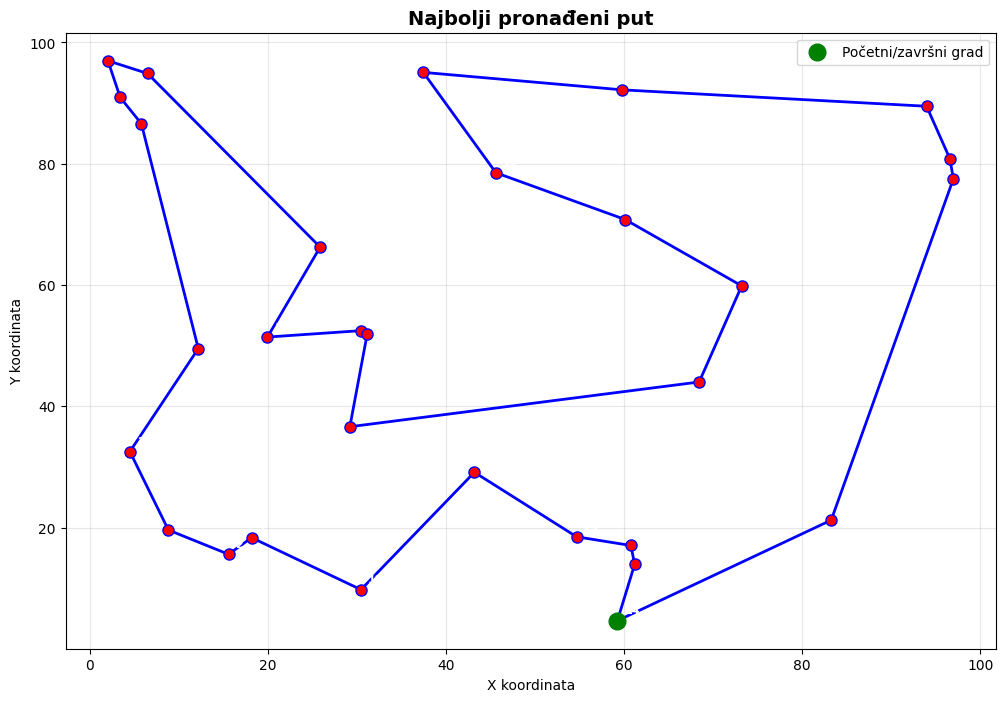

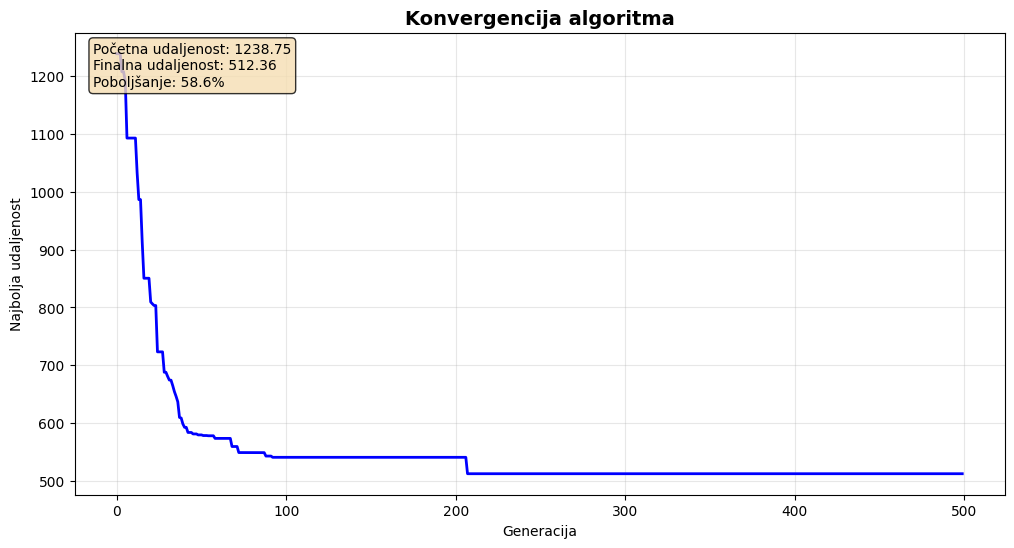


Analiza algoritma završena!


In [ ]:
if __name__ == "__main__":
    print("=" * 60)
    print("TRAVELING SALESMAN PROBLEM - GENETSKI ALGORITAM")
    print("=" * 60)

    # Pokretanje genetskog algoritma
    best_route, fitness_history = genetic_algorithm(
        cities, distance_matrix, verbose=True
    )

    # Prikaz rezultata
    final_distance = calculate_total_distance(best_route, distance_matrix)
    print(f"\nNajbolja pronađena ruta: {best_route}")
    print(f"Ukupna udaljenost: {final_distance:.2f}")

    # Vizualizacija
    plot_route(cities, best_route)
    plot_convergence(fitness_history)

    print("\nAnaliza algoritma završena!")